In [ ]:
# ============================================================
# PERFORMANCE ANALYSIS OF BULLY AND RING ELECTION ALGORITHMS
# ============================================================

# ------------------------------------------------------------
# CELL 1: Import Libraries
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from IPython.display import display

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ------------------------------------------------------------
# CELL 2: Upload Dataset
# ------------------------------------------------------------

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("File:", filename)
print("Shape:", df.shape)

display(df.head())

Saving bully_ring_election_dataset.csv to bully_ring_election_dataset (1).csv
Dataset loaded successfully!
File: bully_ring_election_dataset (1).csv
Shape: (1000, 17)


,Algorithm,Number of Nodes,Failed Nodes,Active Nodes,Failure Rate %,Failure Condition,Coordinator Failure,Initiator Node,Coordinator Node,Messages Sent,Election Rounds,Election Time (ms),Success/Failure,Execution Run,Random Seed,Messages per Active Node,Time per Active Node
0,Bully,5,0,5,0,no failure,No,2,1,13,4,8.814,Success,1,20760111,2.6,1.7628
1,Bully,5,0,5,0,no failure,No,1,3,20,3,7.757,Success,2,20760112,4.0,1.5514
2,Bully,5,0,5,0,no failure,No,3,3,15,4,9.463,Success,3,20760113,3.0,1.8926
3,Bully,5,0,5,0,no failure,No,4,2,12,5,7.740,Success,4,20760114,2.4,1.5480
4,Bully,5,0,5,0,no failure,No,1,1,16,5,7.797,Success,5,20760115,3.2,1.5594


In [ ]:
# ------------------------------------------------------------
# CELL 3: Basic Dataset Information
# ------------------------------------------------------------

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (1000, 17)

Column Names:
['Algorithm', 'Number of Nodes', 'Failed Nodes', 'Active Nodes', 'Failure Rate %', 'Failure Condition', 'Coordinator Failure', 'Initiator Node', 'Coordinator Node', 'Messages Sent', 'Election Rounds', 'Election Time (ms)', 'Success/Failure', 'Execution Run', 'Random Seed', 'Messages per Active Node', 'Time per Active Node']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Algorithm                 1000 non-null   object 
 1   Number of Nodes           1000 non-null   int64  
 2   Failed Nodes              1000 non-null   int64  
 3   Active Nodes              1000 non-null   int64  
 4   Failure Rate %            1000 non-null   int64  
 5   Failure Condition         1000 non-null   object 
 6   Coordinator Failure       1000 non-null   object 
 7   Initi

,0
Algorithm,0
Number of Nodes,0
Failed Nodes,0
Active Nodes,0
Failure Rate %,0
Failure Condition,0
Coordinator Failure,0
Initiator Node,0
Coordinator Node,0
Messages Sent,0



Duplicate Rows: 0


In [ ]:
# ------------------------------------------------------------
# CELL 4: Clean Column Names
# ------------------------------------------------------------

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("%", "percent", regex=False)
)

print("Updated Columns:")
print(df.columns.tolist())

Updated Columns:
['algorithm', 'number_of_nodes', 'failed_nodes', 'active_nodes', 'failure_rate_percent', 'failure_condition', 'coordinator_failure', 'initiator_node', 'coordinator_node', 'messages_sent', 'election_rounds', 'election_time_(ms)', 'success/failure', 'execution_run', 'random_seed', 'messages_per_active_node', 'time_per_active_node']


In [ ]:
# ------------------------------------------------------------
# CELL 5: Display Dataset Statistics
# ------------------------------------------------------------

display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
algorithm,1000,2,Bully,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
number_of_nodes,1000.0,NaN,NaN,NaN,37.0,35.174383,5.0,10.0,20.0,50.0,100.0
failed_nodes,1000.0,NaN,NaN,NaN,2.29,5.86347,0.0,0.0,1.0,1.0,40.0
active_nodes,1000.0,NaN,NaN,NaN,34.71,33.916902,3.0,9.0,19.0,50.0,100.0
failure_rate_percent,1000.0,NaN,NaN,NaN,20.0,14.149212,0.0,10.0,20.0,30.0,40.0
failure_condition,1000,7,no failure,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coordinator_failure,1000,2,No,800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
initiator_node,1000.0,NaN,NaN,NaN,19.355,22.669338,1.0,4.0,9.0,27.0,100.0
coordinator_node,1000.0,NaN,NaN,NaN,19.801,23.168603,1.0,4.0,9.0,28.0,100.0
messages_sent,1000.0,NaN,NaN,NaN,813.892,1823.132166,10.0,26.0,93.5,280.25,11277.0


In [ ]:
# ------------------------------------------------------------
# CELL 6: Convert Important Columns to Numeric
# ------------------------------------------------------------

numeric_columns = [
    "number_of_nodes",
    "failed_nodes",
    "active_nodes",
    "failure_rate_percent",
    "coordinator_failure",
    "initiator_node",
    "coordinator_node",
    "messages_sent",
    "election_rounds",
    "election_time_ms",
    "execution_run",
    "random_seed",
    "messages_per_active_node",
    "time_per_active_node"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Numeric conversion completed.")

Numeric conversion completed.


In [ ]:
# ------------------------------------------------------------
# CELL 7: Check Algorithms
# ------------------------------------------------------------

print("Algorithms present in dataset:")
print(df["algorithm"].value_counts())

print("\nFailure Conditions:")
print(df["failure_condition"].value_counts())

print("\nSuccess / Failure:")
print(df["success/failure"].value_counts())

Algorithms present in dataset:
algorithm
Bully    500
Ring     500
Name: count, dtype: int64

Failure Conditions:
failure_condition
no failure                                 250
multiple failures                          200
single failure                             200
coordinator failure                        200
single failure (no failures at 0%)          50
multiple failures (no failures at 0%)       50
coordinator failure (no failures at 0%)     50
Name: count, dtype: int64

Success / Failure:
success/failure
Success    1000
Name: count, dtype: int64


In [ ]:
# ------------------------------------------------------------
# CELL 8: Overall Performance Comparison
# ------------------------------------------------------------

comparison = df.groupby("algorithm").agg(
    Average_Election_Time_ms=("election_time_(ms)", "mean"),
    Average_Messages=("messages_sent", "mean"),
    Average_Election_Rounds=("election_rounds", "mean"),
    Average_Messages_Per_Active_Node=("messages_per_active_node", "mean"),
    Average_Time_Per_Active_Node=("time_per_active_node", "mean")
).round(3)

display(comparison)

,Average_Election_Time_ms,Average_Messages,Average_Election_Rounds,Average_Messages_Per_Active_Node,Average_Time_Per_Active_Node
algorithm,,,,,
Bully,147.380,1520.534,6.078,24.084,2.923
Ring,20.008,107.250,1.976,3.080,0.726


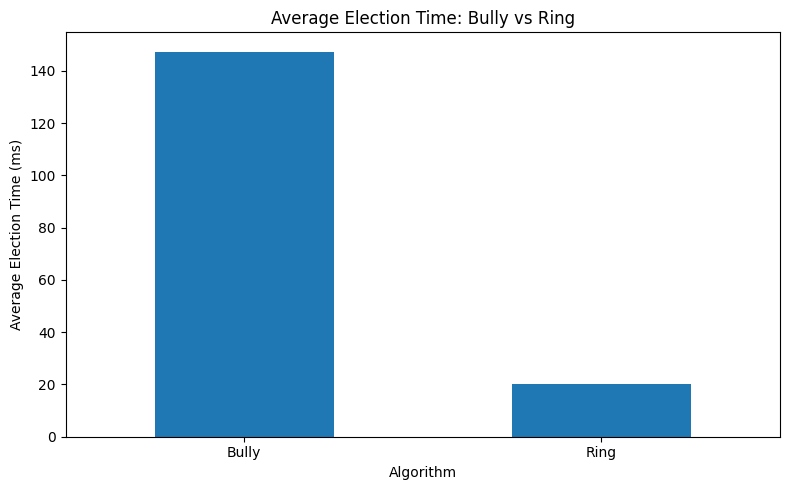

In [ ]:
# ------------------------------------------------------------
# CELL 10: Graph - Average Election Time
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

time_data = df.groupby("algorithm")["election_time_(ms)"].mean()

time_data.plot(kind="bar")

plt.title("Average Election Time: Bully vs Ring")
plt.xlabel("Algorithm")
plt.ylabel("Average Election Time (ms)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

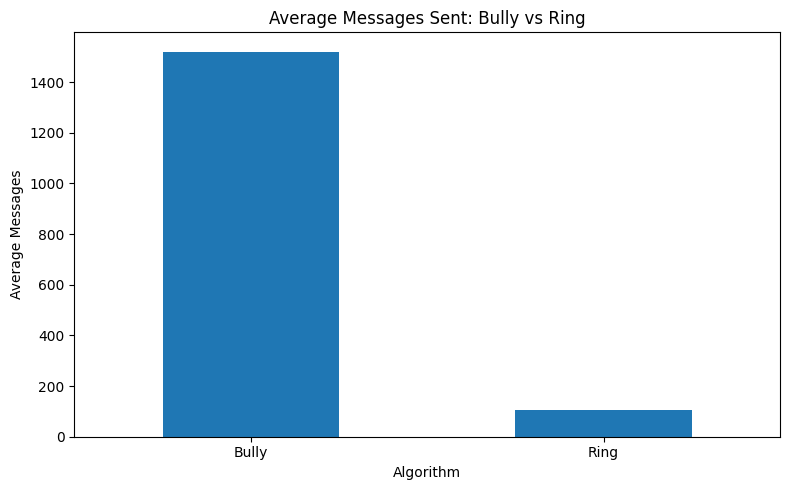

In [ ]:
# ------------------------------------------------------------
# CELL 11: Graph - Average Messages
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

message_data = df.groupby("algorithm")["messages_sent"].mean()

message_data.plot(kind="bar")

plt.title("Average Messages Sent: Bully vs Ring")
plt.xlabel("Algorithm")
plt.ylabel("Average Messages")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

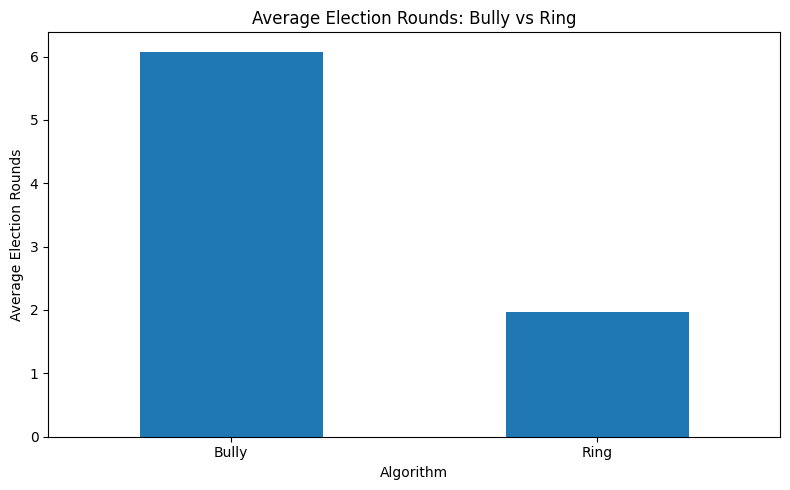

In [ ]:
# ------------------------------------------------------------
# CELL 12: Graph - Election Rounds
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

round_data = df.groupby("algorithm")["election_rounds"].mean()

round_data.plot(kind="bar")

plt.title("Average Election Rounds: Bully vs Ring")
plt.xlabel("Algorithm")
plt.ylabel("Average Election Rounds")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

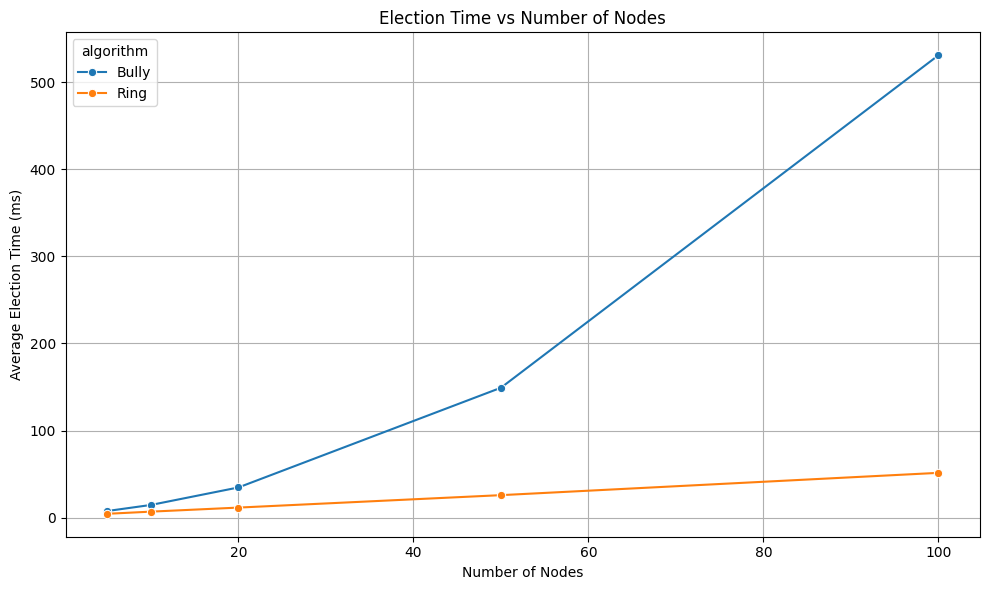

In [ ]:
# ------------------------------------------------------------
# CELL 13: Performance vs Number of Nodes
# ------------------------------------------------------------

node_time = (
    df.groupby(["number_of_nodes", "algorithm"])["election_time_(ms)"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=node_time,
    x="number_of_nodes",
    y="election_time_(ms)",
    hue="algorithm",
    marker="o"
)

plt.title("Election Time vs Number of Nodes")
plt.xlabel("Number of Nodes")
plt.ylabel("Average Election Time (ms)")
plt.grid(True)
plt.tight_layout()
plt.show()

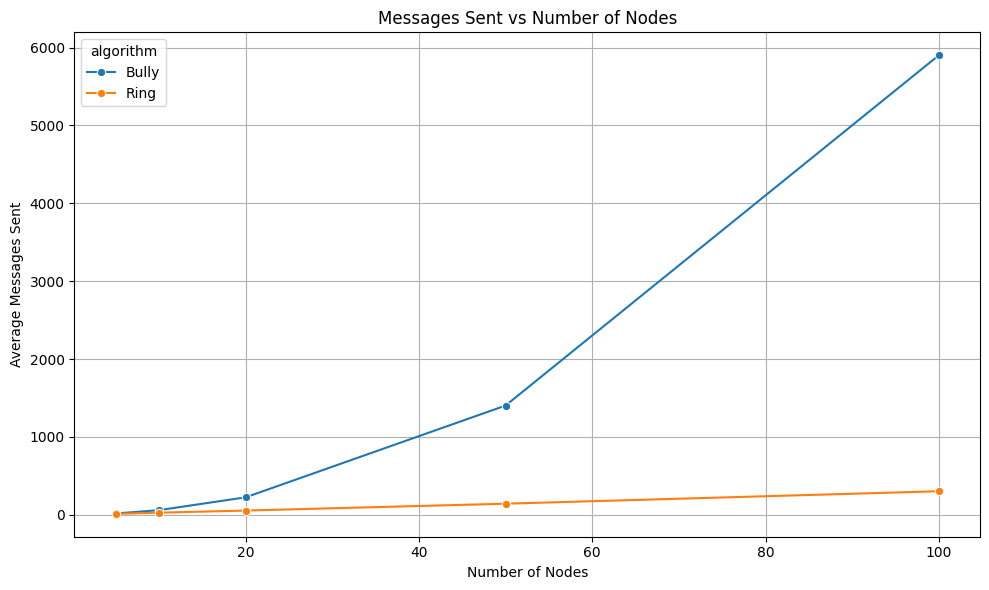

In [ ]:
# ------------------------------------------------------------
# CELL 14: Messages vs Number of Nodes
# ------------------------------------------------------------

node_messages = (
    df.groupby(["number_of_nodes", "algorithm"])["messages_sent"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=node_messages,
    x="number_of_nodes",
    y="messages_sent",
    hue="algorithm",
    marker="o"
)

plt.title("Messages Sent vs Number of Nodes")
plt.xlabel("Number of Nodes")
plt.ylabel("Average Messages Sent")
plt.grid(True)
plt.tight_layout()
plt.show()

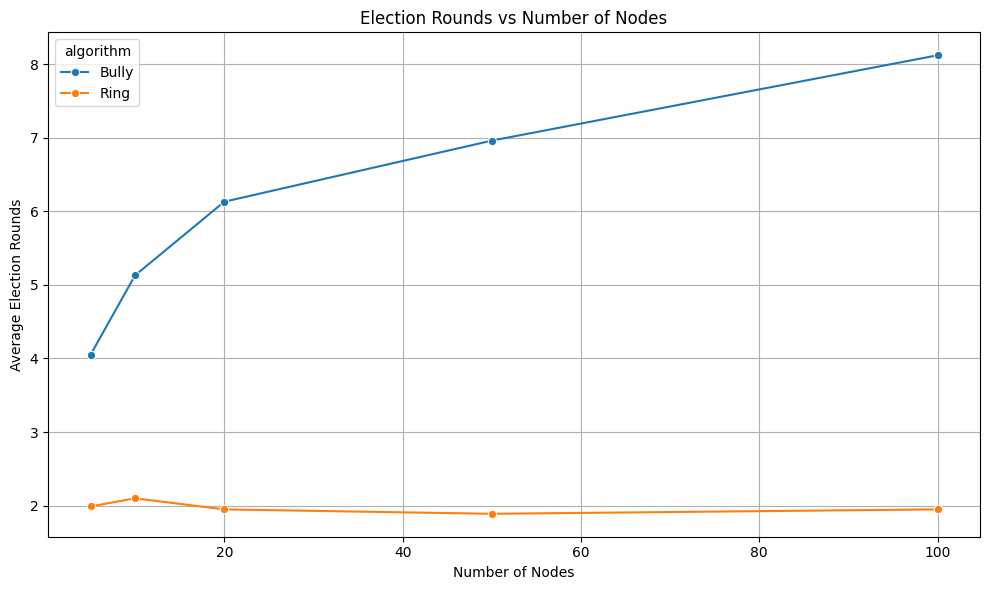

In [ ]:
# ------------------------------------------------------------
# CELL 15: Election Rounds vs Number of Nodes
# ------------------------------------------------------------

node_rounds = (
    df.groupby(["number_of_nodes", "algorithm"])["election_rounds"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=node_rounds,
    x="number_of_nodes",
    y="election_rounds",
    hue="algorithm",
    marker="o"
)

plt.title("Election Rounds vs Number of Nodes")
plt.xlabel("Number of Nodes")
plt.ylabel("Average Election Rounds")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# CELL 16: Failure Rate Analysis
# ------------------------------------------------------------

failure_analysis = (
    df.groupby(["failure_rate_percent", "algorithm"])
    .agg(
        Average_Time_ms=("election_time_(ms)", "mean"),
        Average_Messages=("messages_sent", "mean"),
        Average_Rounds=("election_rounds", "mean")
    )
    .reset_index()
)

display(failure_analysis)

,failure_rate_percent,algorithm,Average_Time_ms,Average_Messages,Average_Rounds
0,0,Bully,135.15130,1332.21,6.03
1,0,Ring,18.94390,99.80,1.97
2,10,Bully,141.85021,1435.95,6.07
3,10,Ring,19.44986,104.55,1.99
4,20,Bully,147.90094,1525.57,6.13
5,20,Ring,19.92227,107.99,2.05
6,30,Bully,153.04911,1611.28,6.07
7,30,Ring,20.57814,110.29,1.96
8,40,Bully,158.94729,1697.66,6.09
9,40,Ring,21.14434,113.62,1.91


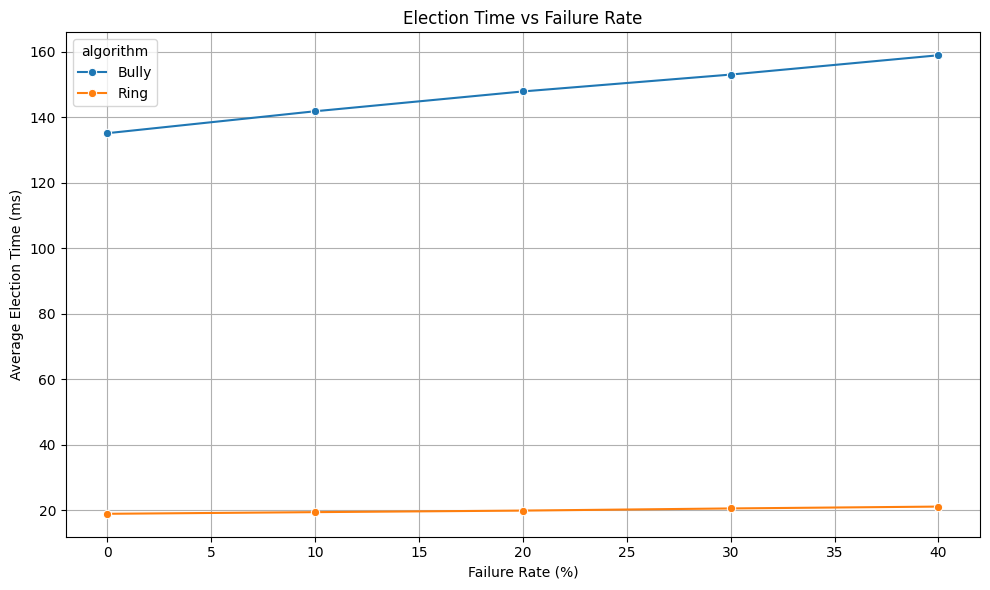

In [ ]:
# ------------------------------------------------------------
# CELL 17: Election Time vs Failure Rate
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

sns.lineplot(
    data=failure_analysis,
    x="failure_rate_percent",
    y="Average_Time_ms",
    hue="algorithm",
    marker="o"
)

plt.title("Election Time vs Failure Rate")
plt.xlabel("Failure Rate (%)")
plt.ylabel("Average Election Time (ms)")
plt.grid(True)
plt.tight_layout()
plt.show()

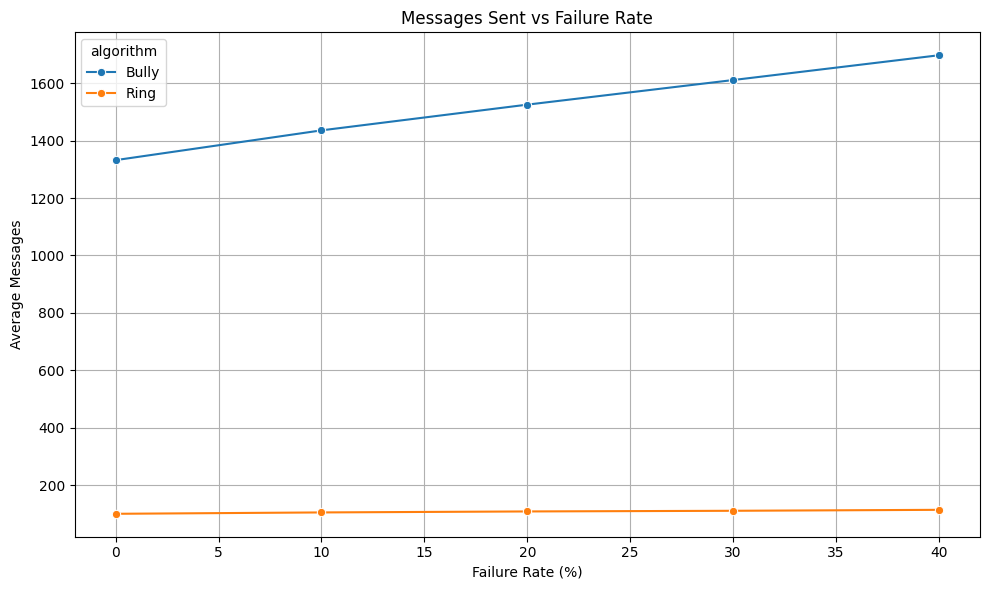

In [ ]:
# ------------------------------------------------------------
# CELL 18: Messages vs Failure Rate
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

sns.lineplot(
    data=failure_analysis,
    x="failure_rate_percent",
    y="Average_Messages",
    hue="algorithm",
    marker="o"
)

plt.title("Messages Sent vs Failure Rate")
plt.xlabel("Failure Rate (%)")
plt.ylabel("Average Messages")
plt.grid(True)
plt.tight_layout()
plt.show()

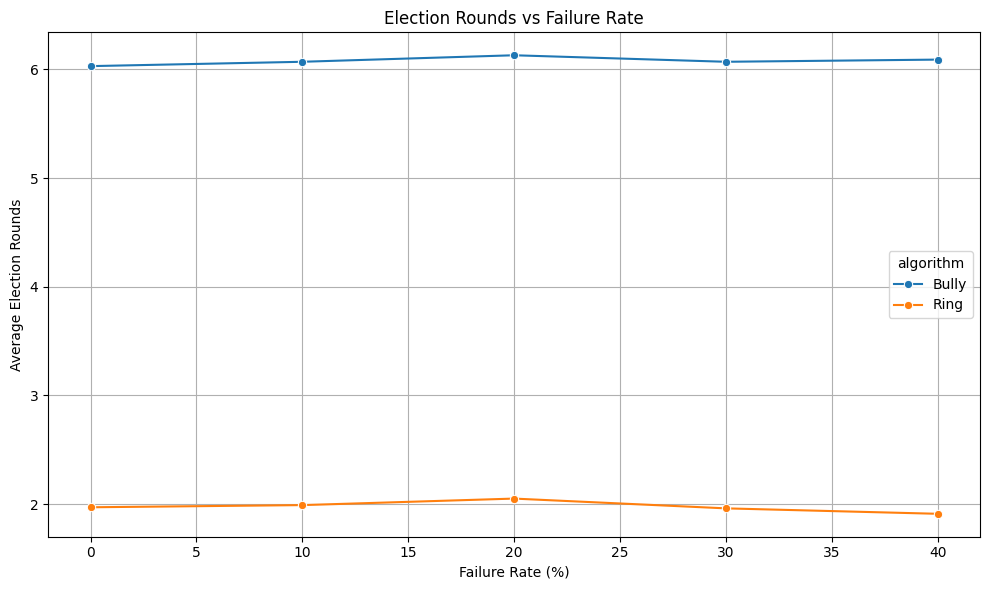

In [ ]:
# ------------------------------------------------------------
# CELL 19: Election Rounds vs Failure Rate
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

sns.lineplot(
    data=failure_analysis,
    x="failure_rate_percent",
    y="Average_Rounds",
    hue="algorithm",
    marker="o"
)

plt.title("Election Rounds vs Failure Rate")
plt.xlabel("Failure Rate (%)")
plt.ylabel("Average Election Rounds")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# CELL 20: Failure Condition Analysis
# ------------------------------------------------------------

condition_analysis = (
    df.groupby(["failure_condition", "algorithm"])
    .agg(
        Average_Time_ms=("election_time_(ms)", "mean"),
        Average_Messages=("messages_sent", "mean"),
        Average_Rounds=("election_rounds", "mean")
    )
    .reset_index()
)

display(condition_analysis)

,failure_condition,algorithm,Average_Time_ms,Average_Messages,Average_Rounds
0,coordinator failure,Bully,137.734340,1371.940,6.100
1,coordinator failure,Ring,18.875620,100.080,1.930
2,coordinator failure (no failures at 0%),Bully,134.121760,1327.240,5.760
3,coordinator failure (no failures at 0%),Ring,18.843760,98.080,2.040
4,multiple failures,Bully,191.027500,2197.260,6.090
5,multiple failures,Ring,24.478740,136.600,2.000
6,multiple failures (no failures at 0%),Bully,135.923760,1338.760,6.360
7,multiple failures (no failures at 0%),Ring,19.089480,100.360,1.920
8,no failure,Bully,135.132720,1331.040,5.992
9,no failure,Ring,18.755368,98.656,2.072


In [ ]:
# ------------------------------------------------------------
# CELL 21: Coordinator Failure Analysis
# ------------------------------------------------------------

if "coordinator_failure" in df.columns:

    coordinator_analysis = (
        df.groupby(["coordinator_failure", "algorithm"])
        .agg(
            Average_Time_ms=("election_time_(ms)", "mean"),
            Average_Messages=("messages_sent", "mean"),
            Average_Rounds=("election_rounds", "mean")
        )
        .reset_index()
    )

    display(coordinator_analysis)

,coordinator_failure,algorithm,Average_Time_ms,Average_Messages,Average_Rounds


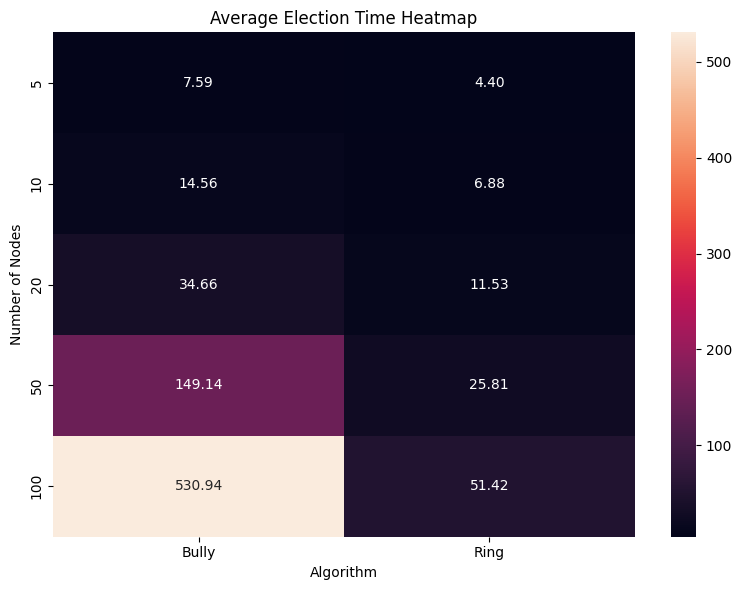

In [ ]:
# ------------------------------------------------------------
# CELL 22: Heatmap - Election Time
# ------------------------------------------------------------

heatmap_data = df.pivot_table(
    values="election_time_(ms)",
    index="number_of_nodes",
    columns="algorithm",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f"
)

plt.title("Average Election Time Heatmap")
plt.xlabel("Algorithm")
plt.ylabel("Number of Nodes")

plt.tight_layout()
plt.show()

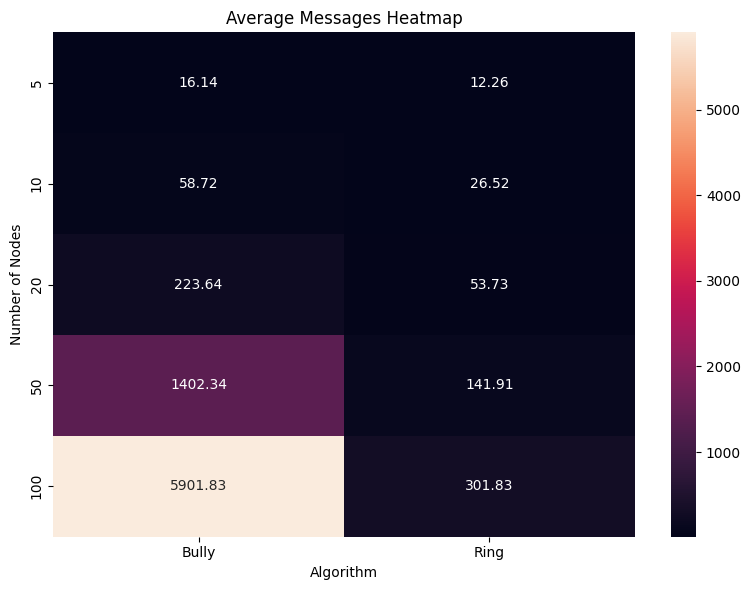

In [ ]:
# ------------------------------------------------------------
# CELL 23: Heatmap - Messages
# ------------------------------------------------------------

heatmap_messages = df.pivot_table(
    values="messages_sent",
    index="number_of_nodes",
    columns="algorithm",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_messages,
    annot=True,
    fmt=".2f"
)

plt.title("Average Messages Heatmap")
plt.xlabel("Algorithm")
plt.ylabel("Number of Nodes")

plt.tight_layout()
plt.show()

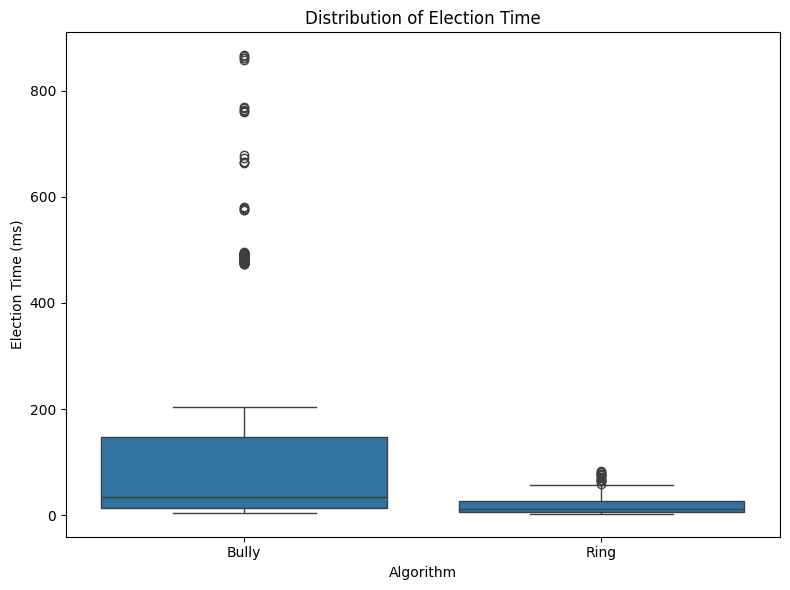

In [ ]:
# ------------------------------------------------------------
# CELL 24: Boxplot - Election Time
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="algorithm",
    y="election_time_(ms)"
)

plt.title("Distribution of Election Time")
plt.xlabel("Algorithm")
plt.ylabel("Election Time (ms)")

plt.tight_layout()
plt.show()

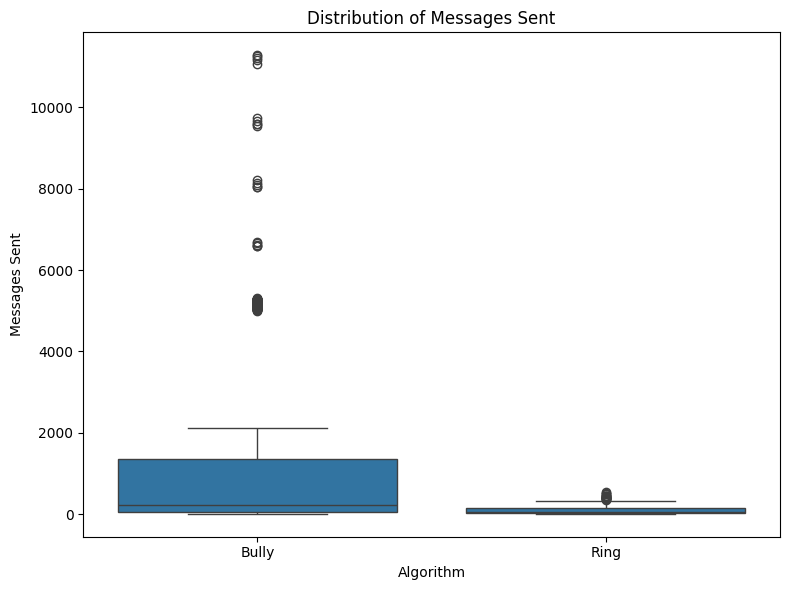

In [ ]:
# ------------------------------------------------------------
# CELL 25: Boxplot - Messages
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="algorithm",
    y="messages_sent"
)

plt.title("Distribution of Messages Sent")
plt.xlabel("Algorithm")
plt.ylabel("Messages Sent")

plt.tight_layout()
plt.show()

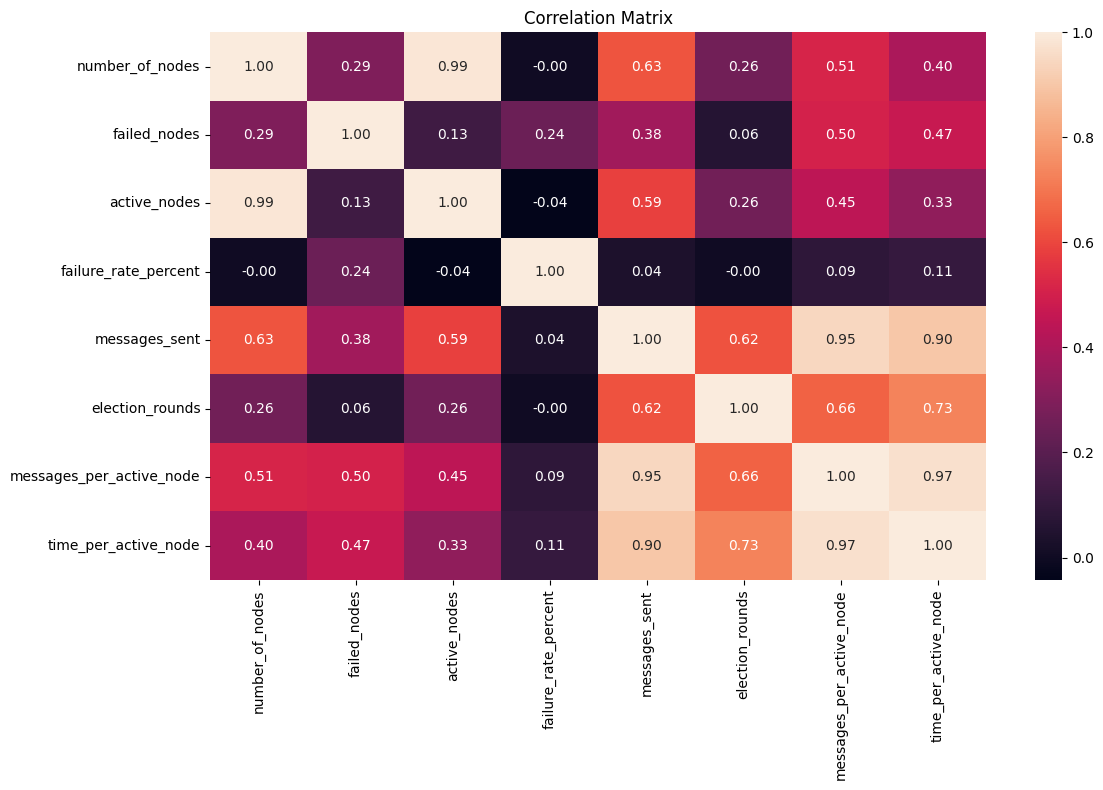

In [ ]:
# ------------------------------------------------------------
# CELL 26: Correlation Analysis
# ------------------------------------------------------------

correlation_columns = [
    "number_of_nodes",
    "failed_nodes",
    "active_nodes",
    "failure_rate_percent",
    "messages_sent",
    "election_rounds",
    "election_time_ms",
    "messages_per_active_node",
    "time_per_active_node"
]

correlation_columns = [
    col for col in correlation_columns if col in df.columns
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# CELL 27: Performance by Node Size
# ------------------------------------------------------------

node_summary = (
    df.groupby(["number_of_nodes", "algorithm"])
    .agg(
        Mean_Time_ms=("election_time_(ms)", "mean"),
        Std_Time_ms=("election_time_(ms)", "std"),
        Mean_Messages=("messages_sent", "mean"),
        Std_Messages=("messages_sent", "std"),
        Mean_Rounds=("election_rounds", "mean"),
        Std_Rounds=("election_rounds", "std")
    )
    .reset_index()
)

node_summary = node_summary.round(3)

display(node_summary)

,number_of_nodes,algorithm,Mean_Time_ms,Std_Time_ms,Mean_Messages,Std_Messages,Mean_Rounds,Std_Rounds
0,5,Bully,7.591,1.331,16.14,2.871,4.05,0.821
1,5,Ring,4.400,1.032,12.26,1.474,1.99,0.772
2,10,Bully,14.561,1.461,58.72,4.895,5.13,0.812
3,10,Ring,6.878,1.037,26.52,2.451,2.10,0.798
4,20,Bully,34.663,2.235,223.64,17.098,6.13,0.812
5,20,Ring,11.531,1.090,53.73,4.958,1.95,0.833
6,50,Bully,149.144,15.316,1402.34,210.839,6.96,0.864
7,50,Ring,25.810,2.740,141.91,19.450,1.89,0.827
8,100,Bully,530.939,105.610,5901.83,1685.620,8.12,0.832
9,100,Ring,51.419,9.706,301.83,67.982,1.95,0.857


In [ ]:
# ------------------------------------------------------------
# CELL 28: Performance by Failure Rate
# ------------------------------------------------------------

failure_summary = (
    df.groupby(["failure_rate_percent", "algorithm"])
    .agg(
        Mean_Time_ms=("election_time_(ms)", "mean"),
        Std_Time_ms=("election_time_(ms)", "std"),
        Mean_Messages=("messages_sent", "mean"),
        Std_Messages=("messages_sent", "std"),
        Mean_Rounds=("election_rounds", "mean"),
        Std_Rounds=("election_rounds", "std")
    )
    .reset_index()
)

failure_summary = failure_summary.round(3)

display(failure_summary)

,failure_rate_percent,algorithm,Mean_Time_ms,Std_Time_ms,Mean_Messages,Std_Messages,Mean_Rounds,Std_Rounds
0,0,Bully,135.151,179.675,1332.21,1944.104,6.03,1.560
1,0,Ring,18.944,15.788,99.80,96.395,1.97,0.810
2,10,Bully,141.850,191.324,1435.95,2135.563,6.07,1.827
3,10,Ring,19.450,16.802,104.55,106.159,1.99,0.810
4,20,Bully,147.901,203.000,1525.57,2335.569,6.13,1.625
5,20,Ring,19.922,18.045,107.99,112.197,2.05,0.809
6,30,Bully,153.049,216.204,1611.28,2566.209,6.07,1.622
7,30,Ring,20.578,19.110,110.29,118.593,1.96,0.852
8,40,Bully,158.947,230.660,1697.66,2823.076,6.09,1.564
9,40,Ring,21.144,20.074,113.62,125.506,1.91,0.818


In [ ]:
# ------------------------------------------------------------
# CELL 29: Statistical Comparison
# ------------------------------------------------------------

from scipy.stats import ttest_ind

bully_time = df[
    df["algorithm"].astype(str).str.lower() == "bully"
]["election_time_(ms)"].dropna()

ring_time = df[
    df["algorithm"].astype(str).str.lower() == "ring"
]["election_time_(ms)"].dropna()

if len(bully_time) > 1 and len(ring_time) > 1:

    t_stat, p_value = ttest_ind(
        bully_time,
        ring_time,
        equal_var=False
    )

    print("Independent t-test")
    print("------------------")
    print("T-statistic:", round(t_stat, 4))
    print("P-value:", round(p_value, 6))

    if p_value < 0.05:
        print("The difference in election time is statistically significant.")
    else:
        print("The difference in election time is not statistically significant.")

Independent t-test
------------------
T-statistic: 13.8867
P-value: 0.0
The difference in election time is statistically significant.


In [ ]:
# ------------------------------------------------------------
# CELL 30: Percentage Difference in Performance
# ------------------------------------------------------------

mean_values = df.groupby("algorithm").agg(
    election_time=("election_time_(ms)", "mean"),
    messages=("messages_sent", "mean"),
    rounds=("election_rounds", "mean")
)

display(mean_values)

if "Bully" in mean_values.index and "Ring" in mean_values.index:

    time_difference = (
        (mean_values.loc["Bully", "election_time"] -
         mean_values.loc["Ring", "election_time"])
        / mean_values.loc["Ring", "election_time"]
    ) * 100

    message_difference = (
        (mean_values.loc["Bully", "messages"] -
         mean_values.loc["Ring", "messages"])
        / mean_values.loc["Ring", "messages"]
    ) * 100

    print("Percentage difference in election time:",
          round(time_difference, 2), "%")

    print("Percentage difference in messages:",
          round(message_difference, 2), "%")

,election_time,messages,rounds
algorithm,,,
Bully,147.379770,1520.534,6.078
Ring,20.007702,107.250,1.976


Percentage difference in election time: 636.62 %
Percentage difference in messages: 1317.75 %


In [ ]:
# ------------------------------------------------------------
# CELL 31: Generate Final Performance Table
# ------------------------------------------------------------

final_analysis = df.groupby("algorithm").agg(
    Total_Executions=("algorithm", "count"),
    Avg_Election_Time_ms=("election_time_(ms)", "mean"),
    Min_Election_Time_ms=("election_time_(ms)", "min"),
    Max_Election_Time_ms=("election_time_(ms)", "max"),
    Avg_Messages=("messages_sent", "mean"),
    Min_Messages=("messages_sent", "min"),
    Max_Messages=("messages_sent", "max"),
    Avg_Election_Rounds=("election_rounds", "mean"),
    Avg_Messages_Per_Active_Node=("messages_per_active_node", "mean"),
    Avg_Time_Per_Active_Node=("time_per_active_node", "mean")
).round(3)

display(final_analysis)

,Total_Executions,Avg_Election_Time_ms,Min_Election_Time_ms,Max_Election_Time_ms,Avg_Messages,Min_Messages,Max_Messages,Avg_Election_Rounds,Avg_Messages_Per_Active_Node,Avg_Time_Per_Active_Node
algorithm,,,,,,,,,,
Bully,500,147.380,5.094,866.548,1520.534,12,11277,6.078,24.084,2.923
Ring,500,20.008,2.713,83.180,107.250,10,550,1.976,3.080,0.726


In [ ]:
# ------------------------------------------------------------
# CELL 32: Save Analysis Results
# ------------------------------------------------------------

final_analysis.to_csv(
    "final_algorithm_performance.csv"
)

node_summary.to_csv(
    "performance_by_node_count.csv",
    index=False
)

failure_summary.to_csv(
    "performance_by_failure_rate.csv",
    index=False
)

condition_analysis.to_csv(
    "performance_by_failure_condition.csv",
    index=False
)

print("Analysis files created successfully!")

Analysis files created successfully!


In [ ]:
# ------------------------------------------------------------
# CELL 33: Download Results
# ------------------------------------------------------------

files.download("final_algorithm_performance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>